# 📊 Top 100 Cryptocurrencies: One-Year Market Analysis 2025

**Python Data Visualization Project**

Course: Python

University: YSU

Author: Julia Meyroyan

This project explores one year of historical data for the top 100 cryptocurrencies by market capitalization.
The goal is to understand overall market behavior, price trends, volatility, and performance using visualizations.


## 1. Introduction

Cryptocurrency markets are known for their high volatility and rapid price changes.
In this project, we analyze daily historical data for the top 100 cryptocurrencies over a one-year period.

The main focus is on understanding:
- how cryptocurrency prices change over time,
- how volatile the market is,
- which cryptocurrencies performed best and worst during the year.


## 2. Dataset Overview

The analysis uses three CSV files containing historical and aggregated cryptocurrency data:

- **crypto_historical_365days.csv**  
  Daily time-series data for the top 100 cryptocurrencies, including prices, trading volumes,
  returns, moving averages, and volatility metrics.

- **crypto_monthly_summary.csv**  
  Monthly aggregated statistics such as average prices, total trading volume, and average daily returns.

- **crypto_yearly_performance.csv**  
  Yearly performance summary for each cryptocurrency, including start price, end price,
  and total return percentage.

Together, these datasets allow both detailed time-series analysis and high-level market comparisons.


## 3. Project Approach

To keep the analysis clear and easy to understand, two different perspectives are used:

- **All 100 cryptocurrencies** are used for statistical analysis and market-wide insights.
- **Top 5 cryptocurrencies by market capitalization** are selected for detailed visualizations
  such as price trends, moving averages, and volatility.

This approach allows us to show the overall market behavior while still focusing on the most
well-known and influential cryptocurrencies.


In [2]:
from google.colab import files

# Upload the ZIP file
uploaded = files.upload()

Saving Top 100 Cryptocurrencies.zip to Top 100 Cryptocurrencies.zip


In [3]:
import zipfile

with zipfile.ZipFile('Top 100 Cryptocurrencies.zip', 'r') as zip_ref:
    zip_ref.extractall()

# Cryptocurrency Introduction

# 💰 What is Cryptocurrency?

Cryptocurrency is a **digital money** that exists only on the internet and is secured using **cryptography**

In simple terms, it’s **electronic money** that **no government or bank controls**.  
They operate on a special system called **blockchain**, which is basically a digital ledger recording **all transactions**.

**Examples:** Bitcoin, Ethereum, Solana

---

## ⚡ Key Features

- **Security** – Transactions are recorded in a complex system, making it nearly impossible to steal or delete.
- **Independence from banks** – You can send or receive money **without a bank**.
- **High volatility** – Crypto prices can rise or fall very quickly depending on demand 📈📉.

---

## 🔄 How Price Changes Work

- Many people want to **buy Bitcoin** → Price goes **up** ⬆  
- People start **selling Ethereum** → Price goes **down** ⬇

---

## ⚠️ Risk Factor

With cryptocurrency, you can **gain profits quickly**, but you can **lose just as fast**.  
That’s why many people say crypto is **very uncertain and risky**

📊 Example: Daily Crypto Price Changes



---


Day 1️⃣  
Price: $10  

Note: Գնում ես 1 հատ → արժե $10  

Day 2️⃣  
Price: $12  

Note: Գինը բարձրացել է, եթե վաճառես → շահում ես $2  

Day 3️⃣  
Price: $8

Note: Գինը ընկել է, եթե պահել ես → կորցրել ես $4  

Day 4️⃣  
Price: $15

Note: Գինը կրկին բարձրացել է, եթե վաճառես → ընդհանուր շահում $5  

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
historical_df = pd.read_csv("crypto_historical_365days.csv")
monthly_df = pd.read_csv("crypto_monthly_summary.csv")
yearly_df = pd.read_csv("crypto_yearly_performance.csv")

In [ ]:
historical_df["date"].min(), historical_df["date"].max()

('2024-12-04', '2025-12-03')

The dataset covers approximately one year of daily cryptocurrency market activity.
This confirms that the data represents a full market cycle rather than a short-term snapshot.


In [ ]:
historical_df["coin_id"].nunique()

100

In [ ]:
historical_df = historical_df.sort_values(by=["coin_id", "date"])

In [ ]:
historical_df.reset_index(drop=True, inplace=True)


##  Basic Data Exploration and Statistics

Before creating visualizations, we explore the data to understand general patterns
such as typical price levels, daily returns, and market volatility across cryptocurrencies.
This step helps build intuition about the overall crypto market.


Price statistics (100 coins together)

In [ ]:
historical_df["price"].describe()


,price
count,33364.000000
mean,4935.370689
std,21026.134092
min,0.000002
25%,0.999408
50%,3.373112
75%,190.019842
max,125397.347055


Cryptocurrency prices vary significantly across the market.
This reflects the presence of both large, well-established cryptocurrencies
and smaller, lower-priced projects.


In [ ]:
historical_df["daily_return"].describe()


,daily_return
count,33264.000000
mean,0.006311
std,4.968284
min,-76.575558
25%,-1.614341
50%,0.000000
75%,1.317147
max,346.177143


Daily returns show that cryptocurrency prices can change noticeably from one day to another,
highlighting the high volatility of the market.


In [ ]:
historical_df["volatility_7d"].describe()


,volatility_7d
count,33164.000000
mean,3.341479
std,3.769143
min,0.000000
25%,1.157136
50%,2.928408
75%,4.582064
max,139.182855


Volatility measures how unstable cryptocurrency prices are over short periods.
Higher volatility indicates higher risk and larger price fluctuations.


In [ ]:
historical_df["market_cap"].describe()


,market_cap
count,3.336400e+04
mean,3.740995e+10
std,2.170265e+11
min,0.000000e+00
25%,1.484588e+09
50%,3.059569e+09
75%,8.223864e+09
max,2.486073e+12


Market cap = գին × շրջանառվող coin-ների քանակ

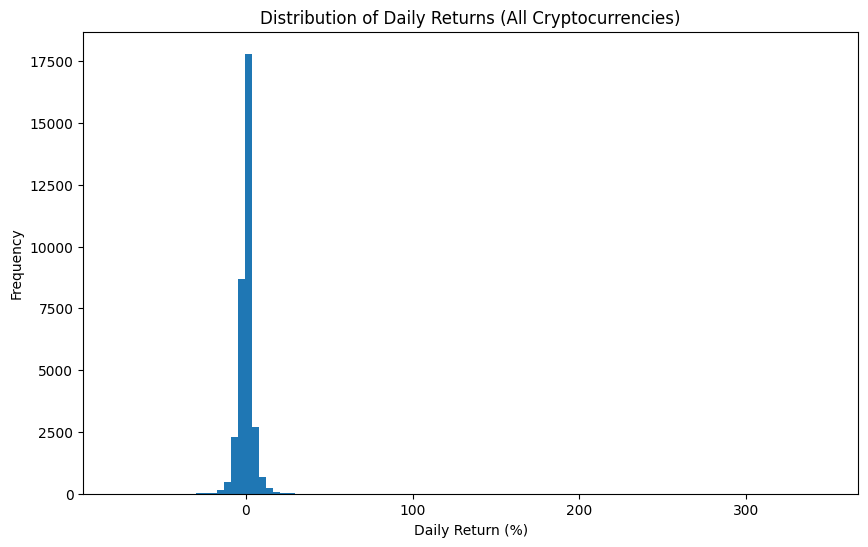

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(historical_df["daily_return"].dropna(), bins=100)
plt.title("Distribution of Daily Returns (All Cryptocurrencies)")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.show()

##**Observation 1.**
Most daily price changes are concentrated around zero, indicating relatively small movements on most days.
However, the long tails show that extreme price changes do occur, highlighting the risky nature of
cryptocurrency markets.


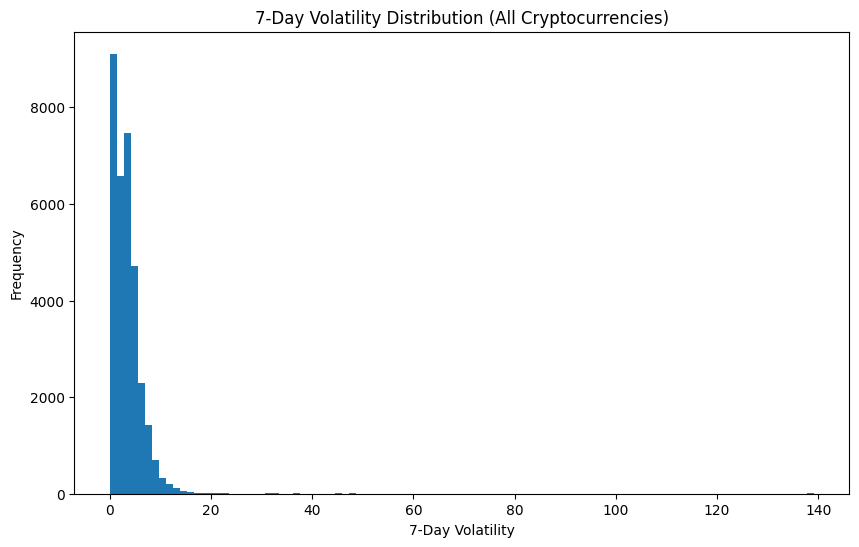

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(historical_df["volatility_7d"].dropna(), bins=100)
plt.title("7-Day Volatility Distribution (All Cryptocurrencies)")
plt.xlabel("7-Day Volatility")
plt.ylabel("Frequency")
plt.show()


##**Observation 2.**
While many cryptocurrencies have moderate volatility,
a smaller group experiences very high price instability, increasing investment risk.


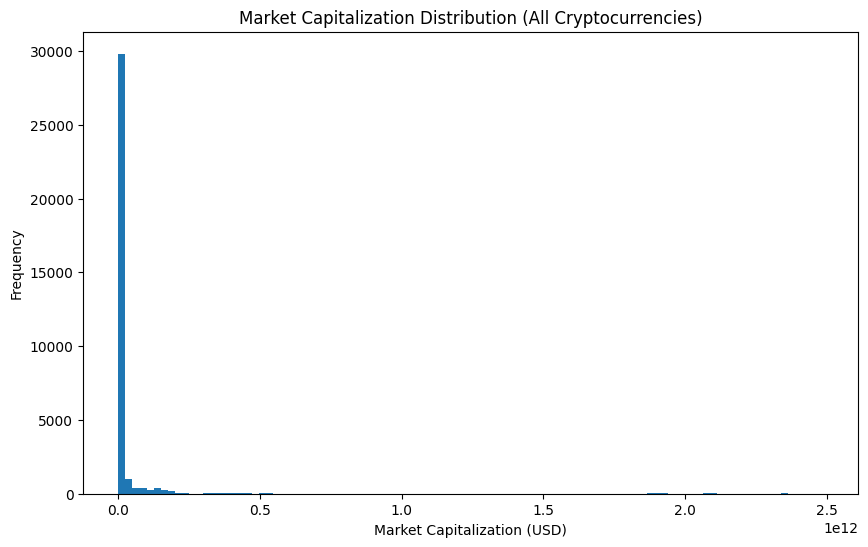

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(historical_df["market_cap"].dropna(), bins=100)
plt.title("Market Capitalization Distribution (All Cryptocurrencies)")
plt.xlabel("Market Capitalization (USD)")
plt.ylabel("Frequency")
plt.show()


##**Observation 3.**
The market capitalization distribution is highly skewed.
A small number of cryptocurrencies dominate the market, while most projects are relatively small.


**These 3 plots show us that 👇**



The market is mostly calm,
but has extreme days

Risk is not evenly distributed

The market is dominated by a few major coins

Now let's select from the dataset top 5 cryptocurrencies based on market capitalization rank. These coins represent the largest and most influential assets in the crypto market during the observed period

In [ ]:
top5_coins = (
    historical_df[["coin_id", "coin_name", "symbol", "market_cap_rank"]]
    .drop_duplicates()
    .sort_values("market_cap_rank")
    .head(5)
)

top5_coins


,coin_id,coin_name,symbol,market_cap_rank
3850,bitcoin,Bitcoin,BTC,1
9295,ethereum,Ethereum,ETH,2
25788,tether,Tether,USDT,3
21805,ripple,XRP,XRP,4
3484,binancecoin,BNB,BNB,5


Let's move on to the price over time chart and for each coin show how the price has changed over the past year.

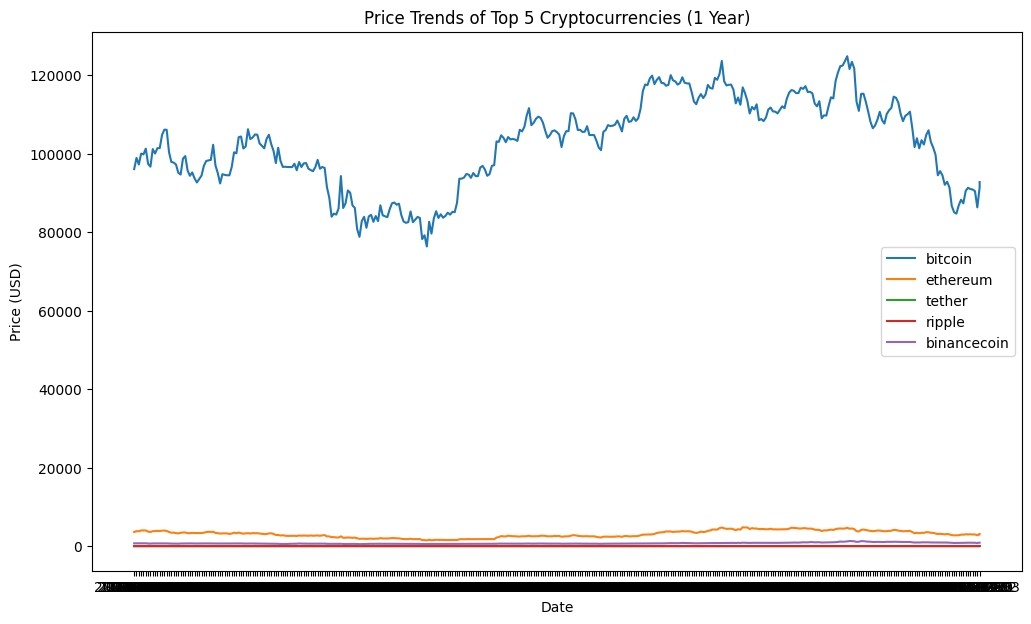

In [ ]:
plt.figure(figsize=(12,7))

for coin in top5_coins["coin_id"]:
    coin_data = historical_df[historical_df["coin_id"] == coin]
    plt.plot(coin_data["date"], coin_data["price"], label=coin)

plt.title("Price Trends of Top 5 Cryptocurrencies (1 Year)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


This plot shows the daily price evolution of the top 5 cryptocurrencies over one year.

##**Observation 4.**
While all coins experience fluctuations, their growth patterns and volatility levels differ significantly, highlighting the diverse behavior within the crypto market.



անցնենք volatility comparison-ին

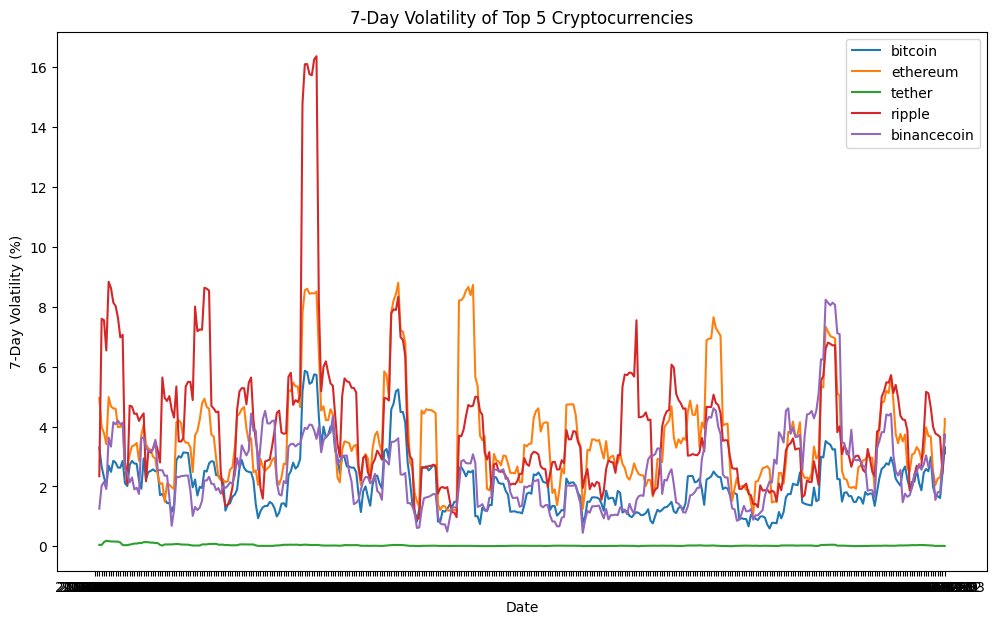

In [ ]:
plt.figure(figsize=(12,7))

for coin in top5_coins["coin_id"]:
    coin_data = historical_df[historical_df["coin_id"] == coin]
    plt.plot(
        coin_data["date"],
        coin_data["volatility_7d"],
        label=coin
    )

plt.title("7-Day Volatility of Top 5 Cryptocurrencies")
plt.xlabel("Date")
plt.ylabel("7-Day Volatility (%)")
plt.legend()
plt.show()


##**Observation 5.**
This chart compares the 7-day volatility of the top 5 cryptocurrencies. We observe that Bitcoin is generally more stable, while Altcoins like ethereum show higher volatility indicating higher risk but also higher potential returns and stablecoins like tether show almost zero volatility.

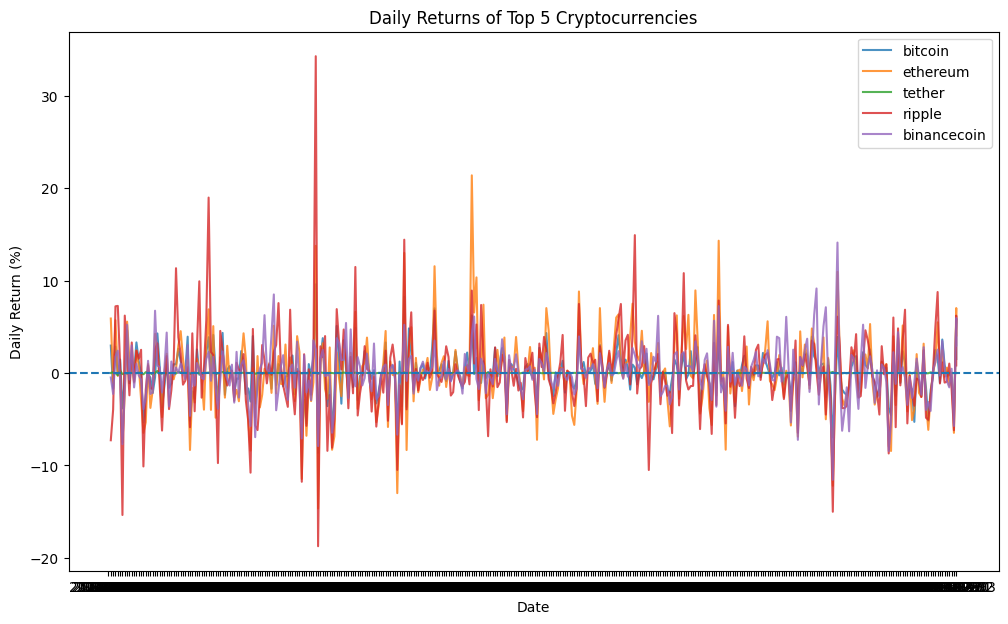

In [ ]:
plt.figure(figsize=(12,7))

for coin in top5_coins["coin_id"]:
    coin_data = historical_df[historical_df["coin_id"] == coin]
    plt.plot(
        coin_data["date"],
        coin_data["daily_return"],
        label=coin,
        alpha=0.8
    )

plt.axhline(0, linestyle="--")  # 0% reference line
plt.title("Daily Returns of Top 5 Cryptocurrencies")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.legend()
plt.show()

##**Conclusion**

In this project, we analyzed one year of daily historical data for the top 100 cryptocurrencies to understand overall market behavior and individual asset dynamics.

Market-wide analysis revealed that while most daily price changes are relatively small, the crypto market is characterized by extreme volatility and occasional sharp movements.

By focusing on the top 5 cryptocurrencies, we observed clear differences in price trends, volatility, and daily returns. Bitcoin appears more stable compared to altcoins, which exhibit higher risk but also higher potential rewards.

Overall, this analysis highlights that the cryptocurrency market offers significant opportunities, but they come with substantial risk, making data-driven analysis essential for understanding market behavior.

##**Cryptocurrency markets are not just about prices going up or down — they are about understanding risk, behavior, and uncertainty. Data visualization allows us to turn complexity into clarity.**